In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

project_path = '/content/drive/MyDrive/MSIL Project/ML Project'

os.listdir(project_path)

['1782894999_project_1.pdf',
 'datasets.zip',
 '1739526192_rolling_stones_spotify.zip',
 '1739525820_creating_cohorts_of_songs_problem_statement.docx',
 '1739525883_datadictionarycreatingcohortsofsongs.zip',
 '1739525570_employee_turnover_problem_statement.docx',
 '1739525599_hr_comma_sep.zip',
 'PROEJCT 1.ipynb',
 'hr_dataset']

In [ ]:
import os
import zipfile

zip_path = os.path.join(
    project_path,
    '1739525599_hr_comma_sep.zip'
)

extract_path = os.path.join(
    project_path,
    'hr_dataset'
)

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction completed successfully!")
print(os.listdir(extract_path))

Extraction completed successfully!
['HR_comma_sep.csv']


In [ ]:
import pandas as pd
import numpy as np

csv_path = '/content/drive/MyDrive/MSIL Project/ML Project/hr_dataset/HR_comma_sep.csv'

df = pd.read_csv(csv_path)

print("Dataset loaded successfully!")
print("Dataset Shape:", df.shape)

df.head()

Dataset loaded successfully!
Dataset Shape: (14999, 10)


,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,sales,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


In [ ]:
# Display dataset information
print("Dataset Information:")
print("-" * 50)
df.info()

print("\n" + "=" * 50)
print("Missing Values:")
print("-" * 50)
print(df.isnull().sum())

print("\n" + "=" * 50)
print("Duplicate Rows:")
print("-" * 50)
print("Total duplicate rows:", df.duplicated().sum())

print("\n" + "=" * 50)
print("Data Types:")
print("-" * 50)
print(df.dtypes)

print("\n" + "=" * 50)
print("Statistical Summary:")
print("-" * 50)
display(df.describe(include='all'))

Dataset Information:
--------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   sales                  14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB

Missing Values:
--------------------------------------------------
satisfaction_level       0
last_evaluation          0
number_proj

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,sales,salary
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999,14999
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10,3
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,sales,low
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4140,7316
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268,NaN,NaN
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281,NaN,NaN
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000,NaN,NaN
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000,NaN,NaN
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000,NaN,NaN
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000,NaN,NaN


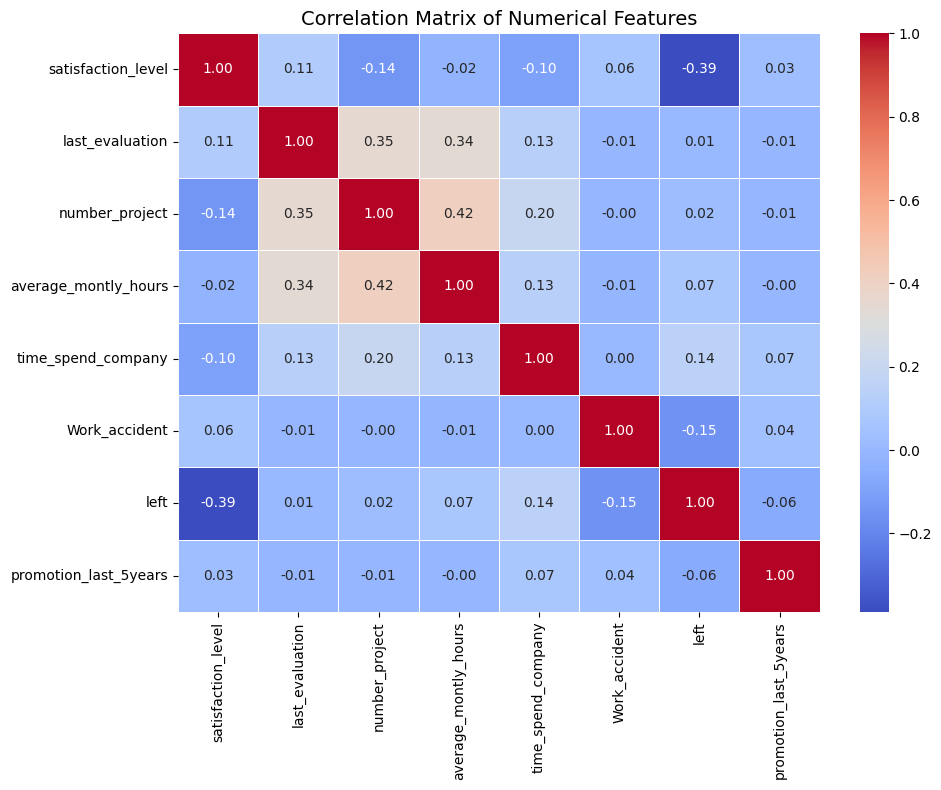

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select numerical columns
numeric_df = df.select_dtypes(include=['number'])

# Create correlation matrix
correlation_matrix = numeric_df.corr()

# Plot heatmap
plt.figure(figsize=(10, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title('Correlation Matrix of Numerical Features', fontsize=14)
plt.tight_layout()
plt.show()

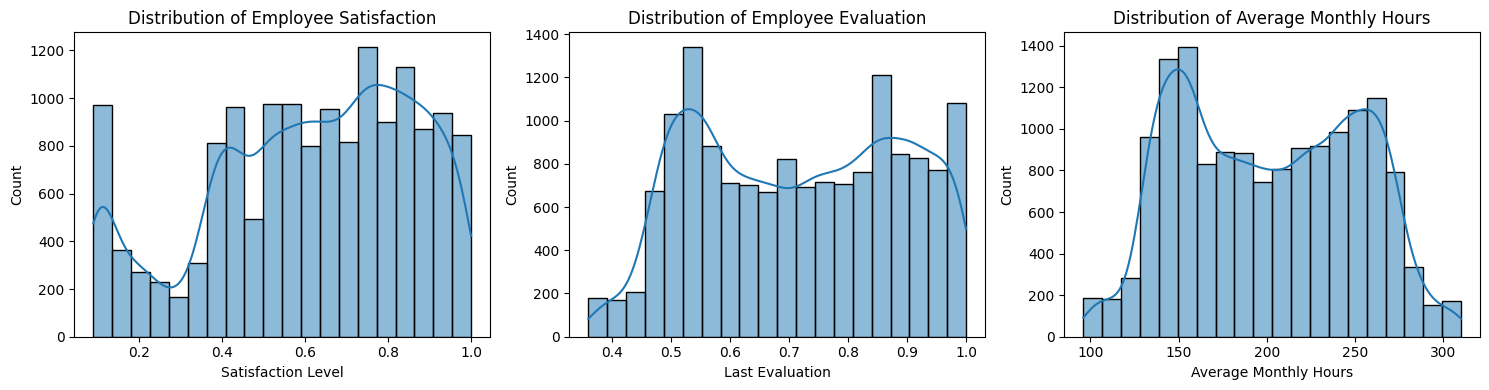

In [ ]:
plt.figure(figsize=(15, 4))

# 1. Satisfaction Level
plt.subplot(1, 3, 1)
sns.histplot(
    data=df,
    x='satisfaction_level',
    kde=True,
    bins=20
)
plt.title('Distribution of Employee Satisfaction')
plt.xlabel('Satisfaction Level')

# 2. Last Evaluation
plt.subplot(1, 3, 2)
sns.histplot(
    data=df,
    x='last_evaluation',
    kde=True,
    bins=20
)
plt.title('Distribution of Employee Evaluation')
plt.xlabel('Last Evaluation')

# 3. Average Monthly Hours
plt.subplot(1, 3, 3)
sns.histplot(
    data=df,
    x='average_montly_hours',
    kde=True,
    bins=20
)
plt.title('Distribution of Average Monthly Hours')
plt.xlabel('Average Monthly Hours')

plt.tight_layout()
plt.show()

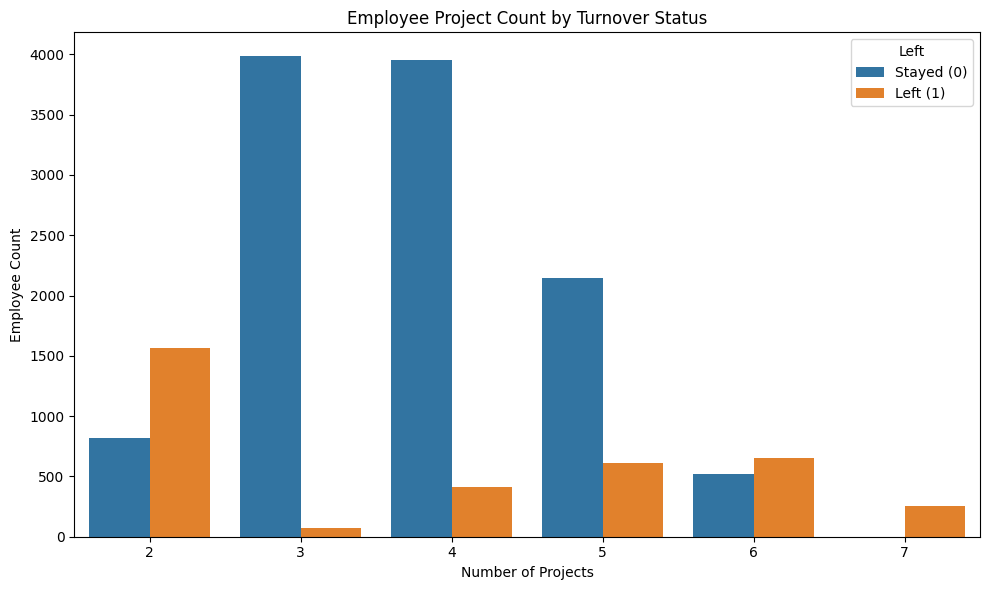

In [ ]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x='number_project',
    hue='left'
)

plt.title('Employee Project Count by Turnover Status')
plt.xlabel('Number of Projects')
plt.ylabel('Employee Count')

plt.legend(
    title='Left',
    labels=['Stayed (0)', 'Left (1)']
)

plt.tight_layout()
plt.show()

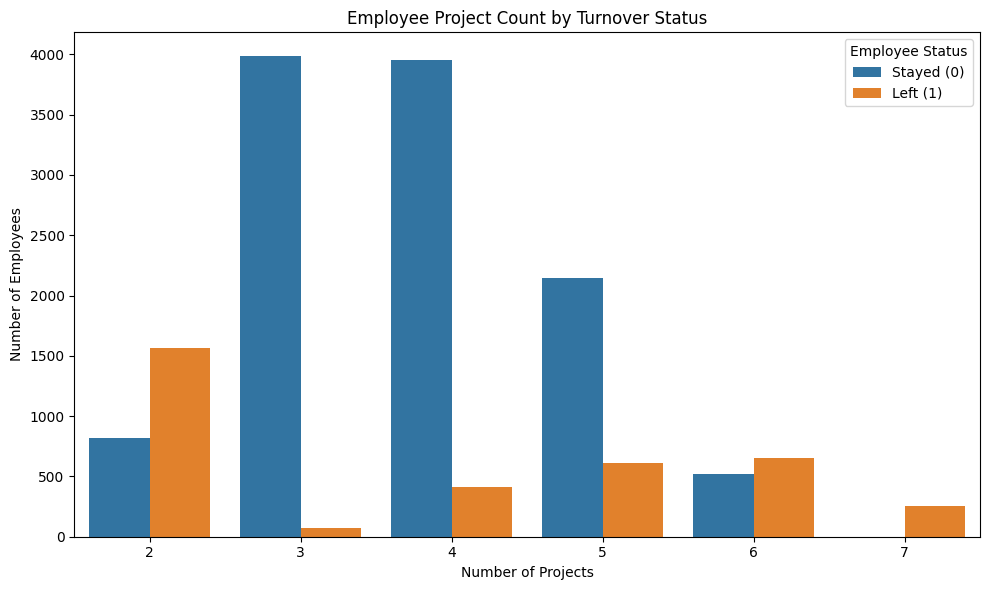

In [ ]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x='number_project',
    hue='left'
)

plt.title('Employee Project Count by Turnover Status')
plt.xlabel('Number of Projects')
plt.ylabel('Number of Employees')

plt.legend(
    title='Employee Status',
    labels=['Stayed (0)', 'Left (1)']
)

plt.tight_layout()
plt.show()

<Axes: xlabel='number_project', ylabel='count'>

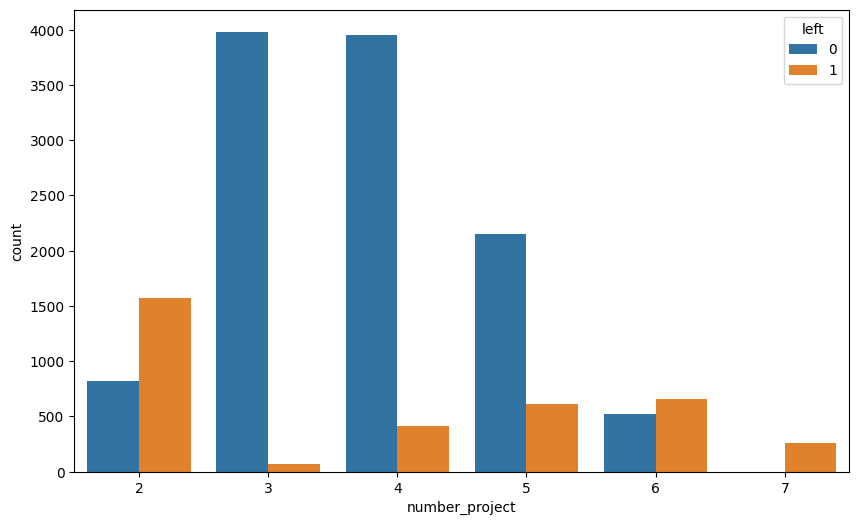

In [ ]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x='number_project',
    hue='left'
)

# Step 11: K-Means Clustering

## Inference: Number of Projects vs Employee Turnover

The analysis shows that employee turnover varies according to the number of projects assigned. Employees with 2 projects and employees with 6 or 7 projects show relatively higher turnover compared with employees working on a moderate number of projects.

This suggests that both underutilization and excessive workload may contribute to employee turnover. Employees with 3 to 5 projects generally show a lower risk of leaving compared with the extreme workload groups.

Therefore, the number of projects should be considered an important workload-related factor when analyzing employee turnover.


In [ ]:
from sklearn.cluster import KMeans

# Select satisfaction, evaluation, and left
cluster_data = df[
    [
        'satisfaction_level',
        'last_evaluation',
        'left'
    ]
].copy()

# Keep only employees who left the company
left_employees = cluster_data[
    cluster_data['left'] == 1
].copy()

# Apply K-Means clustering
kmeans = KMeans(
    n_clusters=3,
    random_state=123,
    n_init=10
)

# Create cluster labels
left_employees['cluster'] = kmeans.fit_predict(
    left_employees[
        [
            'satisfaction_level',
            'last_evaluation'
        ]
    ]
)

left_employees.head()

,satisfaction_level,last_evaluation,left,cluster
0,0.38,0.53,1,1
1,0.80,0.86,1,2
2,0.11,0.88,1,0
3,0.72,0.87,1,2
4,0.37,0.52,1,1


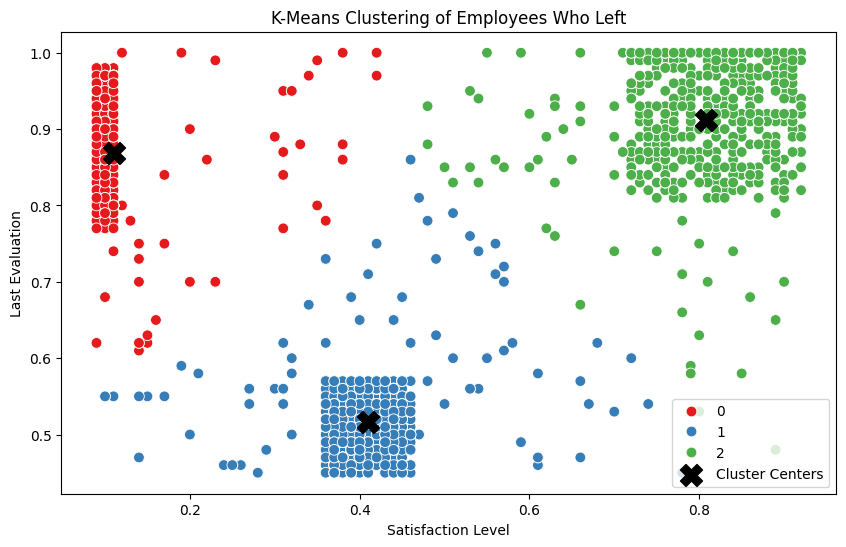

In [ ]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=left_employees,
    x='satisfaction_level',
    y='last_evaluation',
    hue='cluster',
    palette='Set1',
    s=60
)

# Display cluster centers
centers = kmeans.cluster_centers_

plt.scatter(
    centers[:, 0],
    centers[:, 1],
    marker='X',
    s=250,
    c='black',
    label='Cluster Centers'
)

plt.title('K-Means Clustering of Employees Who Left')
plt.xlabel('Satisfaction Level')
plt.ylabel('Last Evaluation')
plt.legend()

plt.show()

## Cluster Interpretation

### Cluster 0
Cluster 0 contains employees with extremely low satisfaction and high evaluation scores. These employees may be capable and productive, but they are highly dissatisfied with their work environment. They represent an important retention risk group.

### Cluster 1
Cluster 1 contains employees with moderate satisfaction and moderate evaluation scores. These employees form the largest cluster among employees who left. Their turnover may be influenced by a combination of workload, career development, compensation, or other organizational factors.

### Cluster 2
Cluster 2 contains employees with high satisfaction and very high evaluation scores. This shows that employee turnover cannot be explained by satisfaction alone. High-performing and satisfied employees may leave because of career opportunities, compensation, promotion opportunities, or external factors.

### Overall Inference
The three clusters demonstrate that employees who leave the organization have different satisfaction and performance profiles. Therefore, retention strategies should not treat all employees as one homogeneous group.

In [ ]:
cluster_summary = left_employees.groupby('cluster').agg(
    employee_count=('cluster', 'size'),
    avg_satisfaction=('satisfaction_level', 'mean'),
    avg_evaluation=('last_evaluation', 'mean')
).round(3)

cluster_summary

,employee_count,avg_satisfaction,avg_evaluation
cluster,,,
0,944,0.111,0.869
1,1650,0.410,0.517
2,977,0.809,0.912


In [ ]:
# Check employee turnover class distribution
print(df['left'].value_counts())

print("\nPercentage Distribution:")
print((df['left'].value_counts(normalize=True) * 100).round(2))

left
0    11428
1     3571
Name: count, dtype: int64

Percentage Distribution:
left
0    76.19
1    23.81
Name: proportion, dtype: float64


## Class Imbalance Analysis

The dataset contains more employees who stayed than employees who left. Therefore, the target variable is imbalanced.

If the model is trained directly on the original training data, it may become biased toward predicting the majority class. To address this problem, SMOTE will be applied only to the training dataset after the train-test split.

The test dataset will remain unchanged so that final model performance can be evaluated on real unseen data.

In [ ]:
# Separate features and target
X = df.drop('left', axis=1)
y = df['left']

# Identify categorical and numerical columns
categorical_columns = X.select_dtypes(include=['object']).columns
numerical_columns = X.select_dtypes(exclude=['object']).columns

print("Categorical Columns:")
print(list(categorical_columns))

print("\nNumerical Columns:")
print(list(numerical_columns))

Categorical Columns:
['sales', 'salary']

Numerical Columns:
['satisfaction_level', 'last_evaluation', 'number_project', 'average_montly_hours', 'time_spend_company', 'Work_accident', 'promotion_last_5years']


In [ ]:
# Convert categorical columns to numerical columns
X_encoded = pd.get_dummies(
    X,
    columns=categorical_columns,
    drop_first=True,
    dtype=int
)

print("Shape after encoding:", X_encoded.shape)
display(X_encoded.head())

Shape after encoding: (14999, 18)


,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,promotion_last_5years,sales_RandD,sales_accounting,sales_hr,sales_management,sales_marketing,sales_product_mng,sales_sales,sales_support,sales_technical,salary_low,salary_medium
0,0.38,0.53,2,157,3,0,0,0,0,0,0,0,0,1,0,0,1,0
1,0.80,0.86,5,262,6,0,0,0,0,0,0,0,0,1,0,0,0,1
2,0.11,0.88,7,272,4,0,0,0,0,0,0,0,0,1,0,0,0,1
3,0.72,0.87,5,223,5,0,0,0,0,0,0,0,0,1,0,0,1,0
4,0.37,0.52,2,159,3,0,0,0,0,0,0,0,0,1,0,0,1,0


## Final Feature Dataset

After converting the categorical variables into numerical dummy variables, the numerical features and encoded categorical features are combined into one final dataset called `X_encoded`.

This dataset will be used as the input for machine learning model training.

Class Distribution:
left
0    11428
1     3571
Name: count, dtype: int64

Percentage Distribution:
left
0    76.19
1    23.81
Name: proportion, dtype: float64


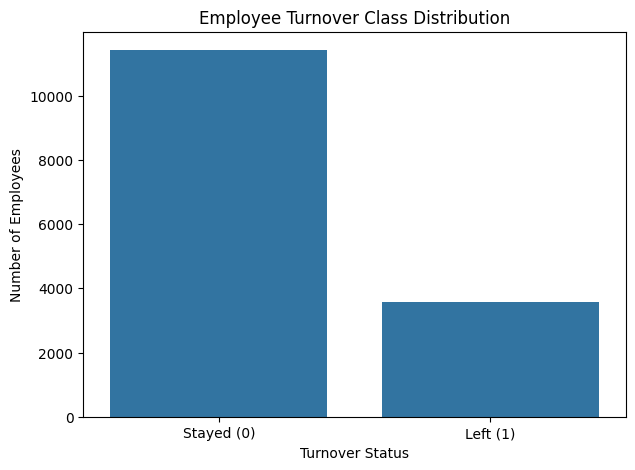

In [ ]:
# Check class distribution
class_counts = df['left'].value_counts().sort_index()

print("Class Distribution:")
print(class_counts)

print("\nPercentage Distribution:")
print((df['left'].value_counts(normalize=True).sort_index() * 100).round(2))

# Visualize class imbalance
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x='left'
)

plt.title('Employee Turnover Class Distribution')
plt.xlabel('Turnover Status')
plt.ylabel('Number of Employees')
plt.xticks([0, 1], ['Stayed (0)', 'Left (1)'])

plt.show()

In [ ]:
# Separate features and target variable
X = df.drop('left', axis=1)
y = df['left']

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (14999, 9)
Target Shape: (14999,)


In [ ]:
# Identify categorical and numerical columns
categorical_columns = X.select_dtypes(include=['object']).columns
numerical_columns = X.select_dtypes(exclude=['object']).columns

print("Categorical Columns:")
print(list(categorical_columns))

print("\nNumerical Columns:")
print(list(numerical_columns))

Categorical Columns:
['sales', 'salary']

Numerical Columns:
['satisfaction_level', 'last_evaluation', 'number_project', 'average_montly_hours', 'time_spend_company', 'Work_accident', 'promotion_last_5years']


In [ ]:
# Apply one-hot encoding to categorical columns
X_encoded = pd.get_dummies(
    X,
    columns=categorical_columns,
    drop_first=True,
    dtype=int
)

print("Original Shape:", X.shape)
print("Encoded Shape:", X_encoded.shape)

display(X_encoded.head())

Original Shape: (14999, 9)
Encoded Shape: (14999, 18)


,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,promotion_last_5years,sales_RandD,sales_accounting,sales_hr,sales_management,sales_marketing,sales_product_mng,sales_sales,sales_support,sales_technical,salary_low,salary_medium
0,0.38,0.53,2,157,3,0,0,0,0,0,0,0,0,1,0,0,1,0
1,0.80,0.86,5,262,6,0,0,0,0,0,0,0,0,1,0,0,0,1
2,0.11,0.88,7,272,4,0,0,0,0,0,0,0,0,1,0,0,0,1
3,0.72,0.87,5,223,5,0,0,0,0,0,0,0,0,1,0,0,1,0
4,0.37,0.52,2,159,3,0,0,0,0,0,0,0,0,1,0,0,1,0


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.20,
    random_state=123,
    stratify=y
)

print("Training Feature Shape:", X_train.shape)
print("Testing Feature Shape:", X_test.shape)

print("\nTraining Target Distribution:")
print(y_train.value_counts())

print("\nTesting Target Distribution:")
print(y_test.value_counts())

Training Feature Shape: (11999, 18)
Testing Feature Shape: (3000, 18)

Training Target Distribution:
left
0    9142
1    2857
Name: count, dtype: int64

Testing Target Distribution:
left
0    2286
1     714
Name: count, dtype: int64


In [ ]:
# If imbalanced-learn is not available, install it
!pip install imbalanced-learn -q

In [ ]:
from imblearn.over_sampling import SMOTE

# Create SMOTE object
smote = SMOTE(
    random_state=123
)

# Apply SMOTE ONLY to training data
X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

print("\nShape Before SMOTE:", X_train.shape)
print("Shape After SMOTE:", X_train_smote.shape)

Before SMOTE:
left
0    9142
1    2857
Name: count, dtype: int64

After SMOTE:
left
0    9142
1    9142
Name: count, dtype: int64

Shape Before SMOTE: (11999, 18)
Shape After SMOTE: (18284, 18)


In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=123
)

scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc'
}

In [ ]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    max_iter=2000,
    random_state=123
)

logistic_cv = cross_validate(
    logistic_model,
    X_train_smote,
    y_train_smote,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

print("LOGISTIC REGRESSION - 5 FOLD CV RESULTS")

for metric in scoring:
    score_name = f'test_{metric}'
    print(
        f"{metric.upper():10}: "
        f"{logistic_cv[score_name].mean():.4f} "
        f"(+/- {logistic_cv[score_name].std():.4f})"
    )

LOGISTIC REGRESSION - 5 FOLD CV RESULTS
ACCURACY  : 0.7895 (+/- 0.0042)
PRECISION : 0.7750 (+/- 0.0044)
RECALL    : 0.8160 (+/- 0.0121)
F1        : 0.7949 (+/- 0.0053)
ROC_AUC   : 0.8496 (+/- 0.0041)


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=123,
    n_jobs=-1
)

rf_cv = cross_validate(
    rf_model,
    X_train_smote,
    y_train_smote,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

print("RANDOM FOREST - 5 FOLD CV RESULTS")

for metric in scoring:
    score_name = f'test_{metric}'
    print(
        f"{metric.upper():10}: "
        f"{rf_cv[score_name].mean():.4f} "
        f"(+/- {rf_cv[score_name].std():.4f})"
    )

RANDOM FOREST - 5 FOLD CV RESULTS
ACCURACY  : 0.9819 (+/- 0.0022)
PRECISION : 0.9934 (+/- 0.0008)
RECALL    : 0.9702 (+/- 0.0046)
F1        : 0.9817 (+/- 0.0022)
ROC_AUC   : 0.9972 (+/- 0.0009)


In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import cross_validate

from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(
    random_state=123
)

gb_cv = cross_validate(
    gb_model,
    X_train_smote,
    y_train_smote,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

print("GRADIENT BOOSTING - 5 FOLD CV RESULTS")

for metric in scoring:
    score_name = f'test_{metric}'
    print(
        f"{metric.upper():10}: "
        f"{gb_cv[score_name].mean():.4f} "
        f"(+/- {gb_cv[score_name].std():.4f})"
    )

GRADIENT BOOSTING - 5 FOLD CV RESULTS
ACCURACY  : 0.9592 (+/- 0.0016)
PRECISION : 0.9752 (+/- 0.0021)
RECALL    : 0.9424 (+/- 0.0036)
F1        : 0.9585 (+/- 0.0017)
ROC_AUC   : 0.9911 (+/- 0.0014)


In [ ]:
cv_results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest',
        'Gradient Boosting'
    ],

    'CV Accuracy': [
        logistic_cv['test_accuracy'].mean(),
        rf_cv['test_accuracy'].mean(),
        gb_cv['test_accuracy'].mean()
    ],

    'CV Precision': [
        logistic_cv['test_precision'].mean(),
        rf_cv['test_precision'].mean(),
        gb_cv['test_precision'].mean()
    ],

    'CV Recall': [
        logistic_cv['test_recall'].mean(),
        rf_cv['test_recall'].mean(),
        gb_cv['test_recall'].mean()
    ],

    'CV F1 Score': [
        logistic_cv['test_f1'].mean(),
        rf_cv['test_f1'].mean(),
        gb_cv['test_f1'].mean()
    ],

    'CV ROC-AUC': [
        logistic_cv['test_roc_auc'].mean(),
        rf_cv['test_roc_auc'].mean(),
        gb_cv['test_roc_auc'].mean()
    ]
})

cv_results = cv_results.sort_values(
    by='CV ROC-AUC',
    ascending=False
).reset_index(drop=True)

cv_results.round(4)

,Model,CV Accuracy,CV Precision,CV Recall,CV F1 Score,CV ROC-AUC
0,Random Forest,0.9819,0.9934,0.9702,0.9817,0.9972
1,Gradient Boosting,0.9592,0.9752,0.9424,0.9585,0.9911
2,Logistic Regression,0.7895,0.7750,0.8160,0.7949,0.8496


In [ ]:
# Logistic Regression
logistic_model.fit(
    X_train_smote,
    y_train_smote
)

# Random Forest
rf_model.fit(
    X_train_smote,
    y_train_smote
)

# Gradient Boosting
gb_model.fit(
    X_train_smote,
    y_train_smote
)

print("All three models trained successfully.")

All three models trained successfully.


## Cross-Validation Model Comparison

The three models are compared using 5-fold cross-validation. Multiple evaluation metrics are considered:

- **Accuracy:** Overall proportion of correct predictions.
- **Precision:** Proportion of predicted employee departures that were actually departures.
- **Recall:** Proportion of actual employee departures correctly identified.
- **F1-score:** Balance between Precision and Recall.
- **ROC-AUC:** Ability of the model to distinguish between employees who stay and employees who leave across different classification thresholds.

ROC-AUC is particularly useful for comparing the overall discriminatory ability of the models. However, Recall is also important because the organization wants to identify employees who are genuinely likely to leave.

In [ ]:
from sklearn.metrics import classification_report

models = {
    'Logistic Regression': logistic_model,
    'Random Forest': rf_model,
    'Gradient Boosting': gb_model
}

for model_name, model in models.items():

    y_pred = model.predict(X_test)

    print("\n")
    print("=" * 70)
    print(model_name)
    print("=" * 70)

    print(
        classification_report(
            y_test,
            y_pred
        )
    )



Logistic Regression
              precision    recall  f1-score   support

           0       0.91      0.75      0.82      2286
           1       0.49      0.75      0.59       714

    accuracy                           0.75      3000
   macro avg       0.70      0.75      0.71      3000
weighted avg       0.81      0.75      0.77      3000



Random Forest
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      2286
           1       0.97      0.98      0.97       714

    accuracy                           0.99      3000
   macro avg       0.98      0.98      0.98      3000
weighted avg       0.99      0.99      0.99      3000



Gradient Boosting
              precision    recall  f1-score   support

           0       0.98      0.97      0.98      2286
           1       0.91      0.94      0.92       714

    accuracy                           0.96      3000
   macro avg       0.95      0.95      0.95      3000
weighted avg    

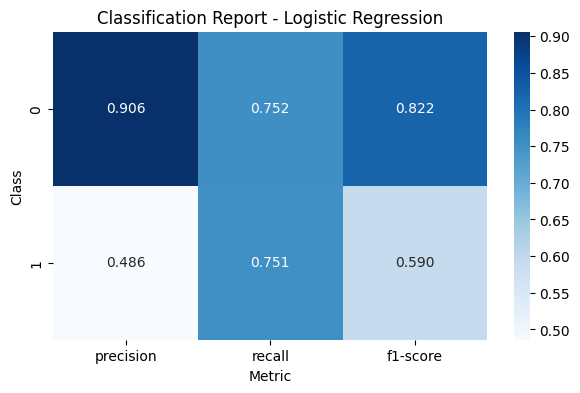

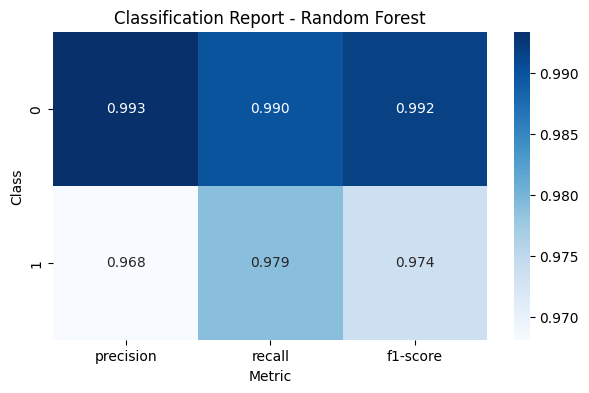

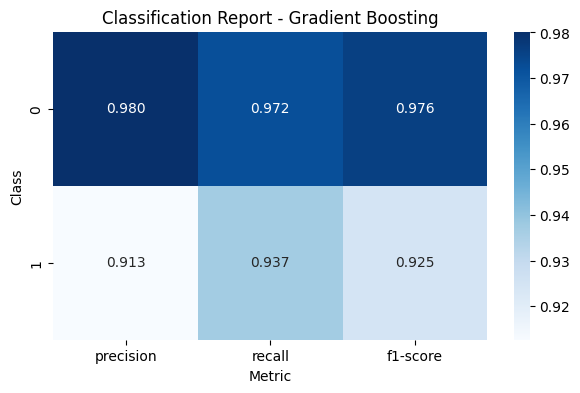

In [ ]:
from sklearn.metrics import classification_report

for model_name, model in models.items():

    y_pred = model.predict(X_test)

    report = classification_report(
        y_test,
        y_pred,
        output_dict=True
    )

    report_df = pd.DataFrame(report).transpose()

    # Keep only class 0 and class 1
    report_df = report_df.loc[
        ['0', '1'],
        ['precision', 'recall', 'f1-score']
    ]

    plt.figure(figsize=(7, 4))

    sns.heatmap(
        report_df,
        annot=True,
        fmt='.3f',
        cmap='Blues'
    )

    plt.title(f'Classification Report - {model_name}')
    plt.ylabel('Class')
    plt.xlabel('Metric')

    plt.show()

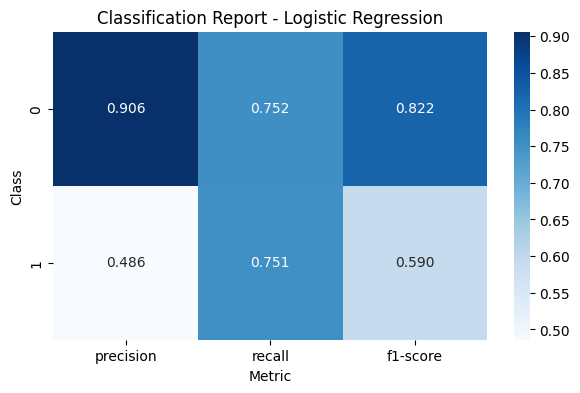

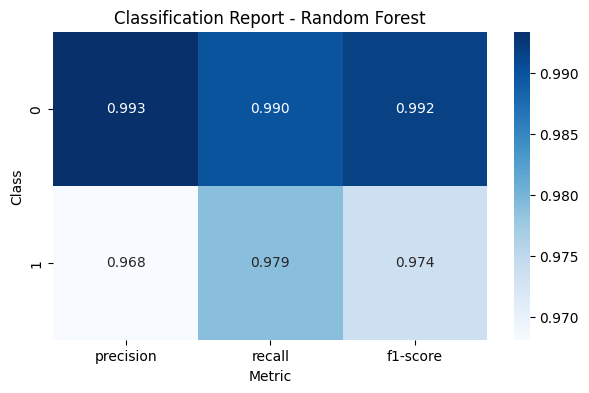

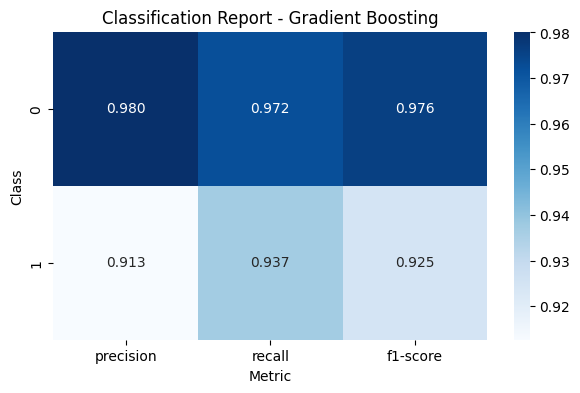

In [ ]:
from sklearn.metrics import classification_report

for model_name, model in models.items():

    y_pred = model.predict(X_test)

    report = classification_report(
        y_test,
        y_pred,
        output_dict=True
    )

    report_df = pd.DataFrame(report).transpose()

    # Keep only class 0 and class 1
    report_df = report_df.loc[
        ['0', '1'],
        ['precision', 'recall', 'f1-score']
    ]

    plt.figure(figsize=(7, 4))

    sns.heatmap(
        report_df,
        annot=True,
        fmt='.3f',
        cmap='Blues'
    )

    plt.title(f'Classification Report - {model_name}')
    plt.ylabel('Class')
    plt.xlabel('Metric')

    plt.show()

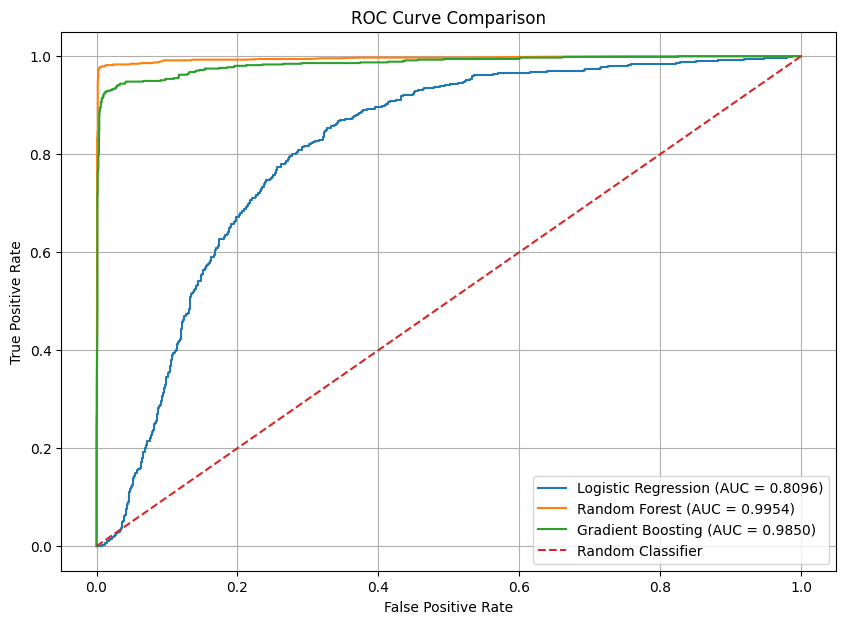

AUC Scores:
Logistic Regression: 0.8096
Random Forest: 0.9954
Gradient Boosting: 0.9850


In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

plt.figure(figsize=(10, 7))

auc_scores = {}

for model_name, model in models.items():

    # Probability of employee leaving
    y_prob = model.predict_proba(X_test)[:, 1]

    # Calculate AUC
    auc_score = roc_auc_score(
        y_test,
        y_prob
    )

    auc_scores[model_name] = auc_score

    # Calculate ROC curve
    fpr, tpr, thresholds = roc_curve(
        y_test,
        y_prob
    )

    plt.plot(
        fpr,
        tpr,
        label=f'{model_name} (AUC = {auc_score:.4f})'
    )

# Random classifier reference line
plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    label='Random Classifier'
)

plt.title('ROC Curve Comparison')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid(True)

plt.show()

print("AUC Scores:")

for model_name, score in auc_scores.items():
    print(f"{model_name}: {score:.4f}")



Logistic Regression
Confusion Matrix:
[[1719  567]
 [ 178  536]]


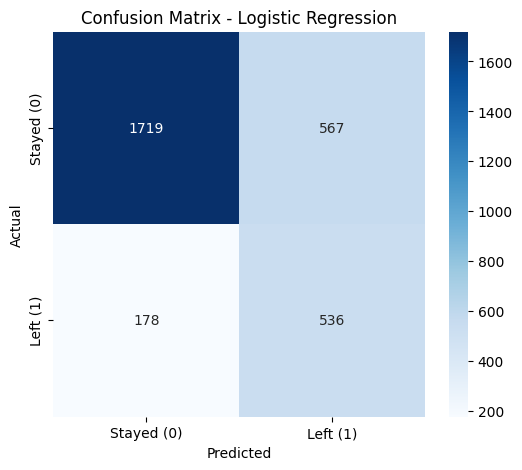



Random Forest
Confusion Matrix:
[[2263   23]
 [  15  699]]


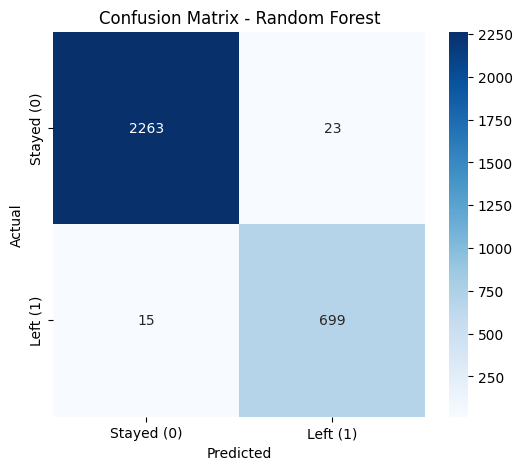



Gradient Boosting
Confusion Matrix:
[[2222   64]
 [  45  669]]


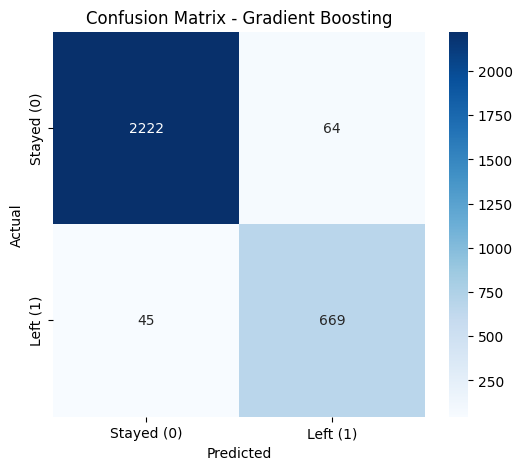

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

for model_name, model in models.items():

    y_pred = model.predict(X_test)

    cm = confusion_matrix(
        y_test,
        y_pred
    )

    print("\n")
    print("=" * 50)
    print(model_name)
    print("=" * 50)

    print("Confusion Matrix:")
    print(cm)

    # Plot confusion matrix
    plt.figure(figsize=(6, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=['Stayed (0)', 'Left (1)'],
        yticklabels=['Stayed (0)', 'Left (1)']
    )

    plt.title(f'Confusion Matrix - {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')

    plt.show()

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

final_results = []

for model_name, model in models.items():

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    final_results.append({
        'Model': model_name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1 Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_prob)
    })

final_results_df = pd.DataFrame(final_results)

final_results_df = final_results_df.sort_values(
    by='ROC-AUC',
    ascending=False
).reset_index(drop=True)

final_results_df.round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Random Forest,0.9873,0.9681,0.9790,0.9735,0.9954
1,Gradient Boosting,0.9637,0.9127,0.9370,0.9247,0.9850
2,Logistic Regression,0.7517,0.4859,0.7507,0.5900,0.8096


## Recall vs Precision

For employee turnover prediction, **Recall is the more important metric**.

Recall measures the percentage of actual employees who leave that are correctly identified by the model.

A **false negative** occurs when the model predicts that an employee will stay, but the employee actually leaves. This is particularly costly because the organization loses the opportunity to take preventive retention action.

Therefore, the organization should prioritize Recall to identify as many employees at risk of leaving as possible.

Precision is also important because unnecessary retention interventions may consume HR resources. Therefore, the final model should consider both Recall and Precision, together with F1-score and ROC-AUC.

For this project, **Recall should be prioritized**, while ROC-AUC is used as an overall metric for comparing the models.

In [ ]:
best_model_name = final_results_df.loc[0, 'Model']

print("Best Model:", best_model_name)
print(
    "Best ROC-AUC:",
    round(
        final_results_df.loc[0, 'ROC-AUC'],
        4
    )
)

best_model = models[best_model_name]

Best Model: Random Forest
Best ROC-AUC: 0.9954


## Best Model Selection
The best model is selected primarily based on ROC-AUC because it measures how effectively a model distinguishes between employees who stay and employees who leave across different probability thresholds.

Based on the test results, Random Forest is the best-performing model.

It achieved:

- Accuracy: 0.9873
- Precision: 0.9681
- Recall: 0.9790
- F1-score: 0.9735
- ROC-AUC: 0.9954

Therefore, Random Forest is selected as the final model for predicting employee turnover probability.

In [ ]:
# Predict probability that employee will leave
turnover_probability = best_model.predict_proba(
    X_test
)[:, 1]

# Create results dataframe
test_results = X_test.copy()

test_results['Actual_Turnover'] = y_test.values

test_results['Turnover_Probability'] = turnover_probability

test_results['Turnover_Percentage'] = (
    test_results['Turnover_Probability'] * 100
).round(2)

display(
    test_results[
        [
            'Actual_Turnover',
            'Turnover_Probability',
            'Turnover_Percentage'
        ]
    ].head()
)

,Actual_Turnover,Turnover_Probability,Turnover_Percentage
10627,0,0.000,0.0
2703,0,0.625,62.5
6059,0,0.100,10.0
3258,0,0.000,0.0
4565,0,0.025,2.5


In [ ]:
def categorize_risk(probability):

    if probability < 0.20:
        return 'Safe Zone (Green)'

    elif probability < 0.60:
        return 'Low-Risk Zone (Yellow)'

    elif probability <= 0.90:
        return 'Medium-Risk Zone (Orange)'

    else:
        return 'High-Risk Zone (Red)'

In [ ]:
test_results['Risk_Zone'] = (
    test_results['Turnover_Probability']
    .apply(categorize_risk)
)

In [ ]:
risk_order = [
    'Safe Zone (Green)',
    'Low-Risk Zone (Yellow)',
    'Medium-Risk Zone (Orange)',
    'High-Risk Zone (Red)'
]

risk_distribution = (
    test_results['Risk_Zone']
    .value_counts()
    .reindex(risk_order, fill_value=0)
)

print("Risk Zone Distribution:")
display(risk_distribution)

Risk Zone Distribution:


,count
Risk_Zone,
Safe Zone (Green),2150
Low-Risk Zone (Yellow),142
Medium-Risk Zone (Orange),57
High-Risk Zone (Red),651


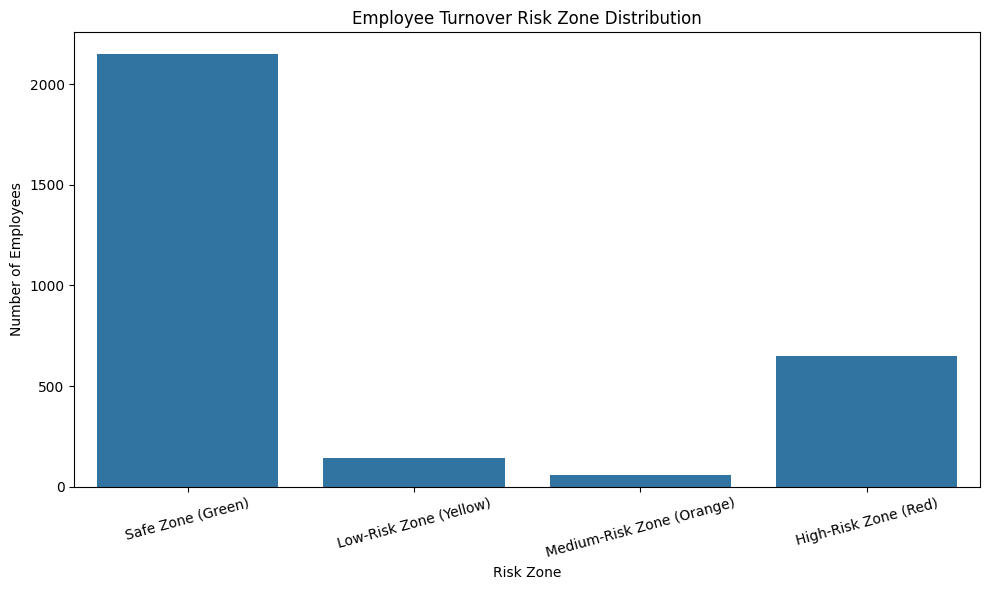

In [ ]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=test_results,
    x='Risk_Zone',
    order=risk_order
)

plt.title('Employee Turnover Risk Zone Distribution')
plt.xlabel('Risk Zone')
plt.ylabel('Number of Employees')

plt.xticks(
    rotation=15
)

plt.tight_layout()
plt.show()

In [ ]:
retention_strategies = pd.DataFrame({

    'Risk Zone': [
        'Safe Zone (Green)',
        'Low-Risk Zone (Yellow)',
        'Medium-Risk Zone (Orange)',
        'High-Risk Zone (Red)'
    ],

    'Turnover Probability': [
        '< 20%',
        '20% - < 60%',
        '60% - < 90%',
        '>= 90%'
    ],

    'Recommended Strategy': [
        'Continue regular engagement, recognition, career development, and employee satisfaction monitoring.',

        'Conduct periodic employee check-ins, provide career growth opportunities, and monitor workload and satisfaction.',

        'Take proactive retention actions, conduct manager discussions, review workload, compensation, promotion opportunities, and work-life balance.',

        'Immediate retention intervention is required. Conduct one-to-one discussions, identify the reasons for potential departure, review compensation and career progression, and provide personalized retention support.'
    ]
})

retention_strategies

,Risk Zone,Turnover Probability,Recommended Strategy
0,Safe Zone (Green),< 20%,"Continue regular engagement, recognition, care..."
1,Low-Risk Zone (Yellow),20% - < 60%,"Conduct periodic employee check-ins, provide c..."
2,Medium-Risk Zone (Orange),60% - < 90%,"Take proactive retention actions, conduct mana..."
3,High-Risk Zone (Red),>= 90%,Immediate retention intervention is required. ...


In [ ]:
risk_summary = (
    test_results
    .groupby('Risk_Zone')
    .agg(
        Employee_Count=(
            'Risk_Zone',
            'size'
        ),

        Average_Turnover_Probability=(
            'Turnover_Probability',
            'mean'
        ),

        Actual_Employees_Left=(
            'Actual_Turnover',
            'sum'
        )
    )
    .reindex(risk_order)
)

risk_summary['Average_Turnover_Probability'] = (
    risk_summary['Average_Turnover_Probability'] * 100
).round(2)

risk_summary

,Employee_Count,Average_Turnover_Probability,Actual_Employees_Left
Risk_Zone,,,
Safe Zone (Green),2150,3.11,10
Low-Risk Zone (Yellow),142,31.95,6
Medium-Risk Zone (Orange),57,78.20,51
High-Risk Zone (Red),651,99.28,647


In [ ]:
print("=" * 70)
print("EMPLOYEE TURNOVER ANALYTICS - FINAL PROJECT SUMMARY")
print("=" * 70)

print(f"\nDataset Shape: {df.shape}")

print(f"\nMissing Values: {df.isnull().sum().sum()}")

print(f"Duplicate Rows: {df.duplicated().sum()}")

print("\nEmployee Turnover Distribution:")
print(
    (df['left']
     .value_counts(normalize=True)
     .sort_index() * 100)
    .round(2)
)

print("\nBest Model:")
print(best_model_name)

print("\nModel Performance:")
display(
    final_results_df.round(4)
)

print("\nRisk Zone Distribution:")
display(
    risk_distribution
    .to_frame(name='Employee Count')
)

print("\nRetention Strategies:")
display(
    retention_strategies
)

print("=" * 70)
print("PROJECT COMPLETED SUCCESSFULLY")
print("=" * 70)

EMPLOYEE TURNOVER ANALYTICS - FINAL PROJECT SUMMARY

Dataset Shape: (14999, 10)

Missing Values: 0
Duplicate Rows: 3008

Employee Turnover Distribution:
left
0    76.19
1    23.81
Name: proportion, dtype: float64

Best Model:
Random Forest

Model Performance:


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Random Forest,0.9873,0.9681,0.9790,0.9735,0.9954
1,Gradient Boosting,0.9637,0.9127,0.9370,0.9247,0.9850
2,Logistic Regression,0.7517,0.4859,0.7507,0.5900,0.8096



Risk Zone Distribution:


,Employee Count
Risk_Zone,
Safe Zone (Green),2150
Low-Risk Zone (Yellow),142
Medium-Risk Zone (Orange),57
High-Risk Zone (Red),651



Retention Strategies:


,Risk Zone,Turnover Probability,Recommended Strategy
0,Safe Zone (Green),< 20%,"Continue regular engagement, recognition, care..."
1,Low-Risk Zone (Yellow),20% - < 60%,"Conduct periodic employee check-ins, provide c..."
2,Medium-Risk Zone (Orange),60% - < 90%,"Take proactive retention actions, conduct mana..."
3,High-Risk Zone (Red),>= 90%,Immediate retention intervention is required. ...


PROJECT COMPLETED SUCCESSFULLY
